# 🏁 Batch Heuristics Pipeline — 6 Drivers × 2 Tracks
**Goal:** Update Section 6.3 (Table 7) of *artigo_iracing_v4*.

Computes physics-informed heuristic activations using **chained proficiency comparisons** (B vs. A; C, D, E, F each vs. B) — the same logic as the original Table 7, extended to 6 drivers — on **both tracks**, with two aggregation levels:

1. **Snapshot (Stint 1)** → replacement for Table 7 (LaTeX booktabs + Gestalt heatmap).
2. **Longitudinal (all stints)** → heuristic counts along stints, same reference comparison.

Reuses functions from `iracing_coaching_pipeline_v2` (config package, heuristics, `DRIVING_RULES`).
Run from `Iracing/Notebooks/` (same location as the v2 notebook).

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

# notebook lives in Iracing/Notebooks/ -> go up one level
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                    basic_clean_and_units, build_lap_validity_table, load_stint)

print(f"Tracks : {list(TRACK_CONFIGS.keys())}")
print(f"Drivers: {DRIVER_ALIAS}")

Tracks : ['charlotte_roval_2025', 'summit_point']
Drivers: {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}


## 1. Batch configuration
`COMPARISONS`: chained proficiency comparisons — **not** a single global reference.
Mirrors the original Table 7 logic, extended to 6 drivers:

- **B vs. A** (Tomaz vs. Rodrigo) — intermediate vs. expert
- **C vs. B**, **D vs. B**, **E vs. B**, **F vs. B** (Morsinaldo/Thallys/Igor/Hilton vs. Tomaz) — each amateur vs. the intermediate

Driver A never appears as `test`; Driver B never appears as `ref` in the amateur group. Each `ref` driver's telemetry is loaded once per track and cached (Tomaz is reused as reference in 4 comparisons).

In [ ]:
# ── Chained comparisons (mirrors original Table 7 logic) ─────────────
# ref_stint is fixed (best/representative lap); test_stint varies for the
# longitudinal analysis. Column labels match the manuscript convention.
COMPARISONS = [
    {"ref": "Rodrigo",     "ref_stint": "stint_1",   "test": "Tomaz",      "label": "B vs. A"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Morsinaldo", "label": "C vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Thallys",    "label": "D vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Igor",       "label": "E vs. B"},
    {"ref": "Tomaz",       "ref_stint": "stint_ref", "test": "Hilton",     "label": "F vs. B"},
]

EXCLUDE_STINTS = {"warmup", "stint_ref"}   # not part of the stint sequence
TRACK_SHORT    = {"charlotte_roval_2025": "CLT", "summit_point": "SPT"}
BASE_GRID_LEN  = 2000

SAVE_DIR = Path(PROJECT_ROOT) / "img" / "batch_heuristics"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {SAVE_DIR}")

Output directory: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\batch_heuristics


## 2. Heuristic functions (identical to pipeline v2)
Copied verbatim from `iracing_coaching_pipeline_v2` to keep this notebook self-contained.
**Do not edit thresholds here** — they must match the manuscript Methods section.

In [ ]:
# --- Derivatives -----------------------------------------------------
def compute_derivatives(sec: dict):
    t  = sec["t_rel"]
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    brake_rate    = np.gradient(sec["brake"], dt)
    throttle_rate = np.gradient(sec["throttle"], dt)
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate    = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)
    return brake_rate, throttle_rate

def braking_heuristics(sec, brake_rate):
    d = {}
    m = sec["brake"] > 0.05
    if np.any(m):
        d["BrakeRampRate"]   = float(np.quantile(brake_rate[m], 0.95))
        d["BrakeConsistency"]= float(np.var(brake_rate[m]))
        d["BrakeEfficiency"] = float(abs(np.min(sec["long_accel"][m])) /
                                     (np.max(sec["brake"][m]) + 1e-6))
    else:
        d["BrakeRampRate"] = d["BrakeConsistency"] = d["BrakeEfficiency"] = 0.0
    return d

def rotation_heuristics(sec):
    d = {}
    speed, yaw, steer, t = sec["speed"], sec["yaw_rate"], sec["steering"], sec["t_rel"]
    idx_vmin = np.argmin(speed)
    idx_mrp  = np.argmax(np.abs(yaw))
    d["Vmin"]           = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(t[idx_vmin] - t[idx_mrp])
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    d["TrailOverlap"] = float((sec["brake"] * np.abs(steer) * dt).sum())
    d["Vmin_Norm"]    = float(d["Vmin"] / (speed[0] + 1e-6))
    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = (float(np.mean(np.abs(yaw)) / (avg_steer + 1e-6))
                               if avg_steer > 1e-3 else 0.0)
    return d

def acceleration_heuristics(sec, throttle_rate):
    d = {}
    m = sec["throttle"] > 0.05
    if np.any(m):
        d["ThrottleAttackRate"]   = float(np.quantile(throttle_rate[m], 0.95))
        d["ThrottleSmoothness"]   = float(1.0 / (np.var(throttle_rate[m]) + 1e-6))
        d["ThrottleSteerConflict"]= float(np.mean(sec["throttle"] * np.abs(sec["steering"])))
        d["AccelEfficiency"]      = float(np.mean(sec["long_accel"][m]) /
                                          (np.mean(sec["throttle"][m]) + 1e-6))
    else:
        d["ThrottleAttackRate"] = d["ThrottleSmoothness"] = 0.0
        d["ThrottleSteerConflict"] = d["AccelEfficiency"] = 0.0
    return d

def sector_heuristics(sec_raw: dict) -> dict:
    sec = {
        "t_rel":      sec_raw["t_rel"],
        "speed":      sec_raw["speed"],
        "brake":      sec_raw["brake"],
        "throttle":   sec_raw["throttle"],
        "steering":   sec_raw["SteeringWheelAngle"],
        "yaw_rate":   sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
    }
    brake_rate, throttle_rate = compute_derivatives(sec)
    h = {
        "SpeedStart": float(sec["speed"][0]),
        "SpeedEnd":   float(sec["speed"][-1]),
        "BrakePeak":  float(np.max(sec["brake"])),
        "SteerRMS":   float(np.sqrt(np.mean(sec["steering"] ** 2))),
    }
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    return h

def compute_sector_heuristics(interp: dict, edges) -> pd.DataFrame:
    if not interp:
        return pd.DataFrame()
    lap_dist = interp["LapDistPct"]
    rows = []
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i + 1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i + 1])
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            continue
        sl = slice(idx[0], idx[-1] + 1)
        sec_raw = {k: v[sl] for k, v in interp.items()}
        sec_raw["t_rel"] = sec_raw["t_rel"] - sec_raw["t_rel"][0]
        h = sector_heuristics(sec_raw)
        h["Sector"]        = i
        h["SectorTime_s"]  = float(sec_raw["t_rel"][-1])
        rows.append(h)
    return pd.DataFrame(rows)

In [ ]:
# --- Lap alignment (same as v2) --------------------------------------
def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray):
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}
    interp = lambda y: np.interp(grid, x, y)
    return {
        "LapDistPct": grid,
        "t_rel":      interp(t_rel.to_numpy()),
        "speed":      interp(g["Speed_KPH"].to_numpy()),
        "throttle":   interp(g["Throttle_Pct"].to_numpy()),
        "brake":      interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":    interp(g.get("YawRate",   pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":  interp(g.get("LongAccel", pd.Series(np.zeros_like(x))).to_numpy()),
    }

## 3. `DRIVING_RULES` — condition-only version
Only rule `id`, `category`, and `condition` are needed to count activations
(coaching messages are irrelevant here). Thresholds are **identical** to pipeline v2.

In [ ]:
DRIVING_RULES = [
    {"id": "R3_LATE_ROTATION", "category": "Rotation",
     "condition": lambda A, B: B.get("Delta_MRP_Vmin", 0) < -0.05},

    {"id": "B3_LOW_BRAKE_EFFICIENCY", "category": "Braking",
     "condition": lambda A, B: B.get("BrakeEfficiency", 0) < A.get("BrakeEfficiency", 0) * 0.85},

    {"id": "R4_POOR_TRAIL_BRAKING", "category": "Rotation",
     "condition": lambda A, B: (B.get("TrailOverlap", 0) < A.get("TrailOverlap", 0) * 0.70 and
                                B.get("Vmin", 0) < A.get("Vmin", 0))},

    {"id": "L1_EXIT_SPEED_LEGACY", "category": "Legacy",
     "condition": lambda A, B: (B.get("SpeedStartDiff", 0) < -2.0 and
                                B.get("BrakePeak", 0) < 0.05)},

    {"id": "B1_BRAKING_POINT_MISMATCH", "category": "Braking",
     "condition": lambda A, B: abs(B.get("BrakeStartDist", 0) - A.get("BrakeStartDist", 0)) > 0.005},

    {"id": "B3_OVER_BRAKING_PEAK", "category": "Braking",
     "condition": lambda A, B: B.get("BrakePeak", 0) > A.get("BrakePeak", 0) + 0.15},

    {"id": "ENTRY_OVER_SLOW", "category": "Braking",
     "condition": lambda A, B: ((B.get("Vmin", 1) - A.get("Vmin", 1)) / (A.get("Vmin", 1) + 1e-6) < -0.015
                                and B.get("BrakePeak", 0) > 5)},

    {"id": "F1_AGGRESSIVE_UNSTABLE_BRAKE", "category": "Braking",
     "condition": lambda A, B: ((B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + 1e-6)) > 1.25 and
                                (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + 1e-6)) > 1.30)},

    {"id": "S1_STEER_EFFICIENCY", "category": "Steering",
     "condition": lambda A, B: B.get("SteerRMS", 0) > A.get("SteerRMS", 0) * 1.20},

    {"id": "R3_ROTATION_INEFFICIENT", "category": "Rotation",
     "condition": lambda A, B: ((B.get("RotationEfficiency", 0) - A.get("RotationEfficiency", 0) < -0.05) and
                                (B.get("Vmin", 0) < A.get("Vmin", 0) * 0.97))},

    {"id": "LATE_THROTTLE_LOW_SPEED", "category": "Exit",
     "condition": lambda A, B: ((B.get("ThrottleSmoothness", 1) < A.get("ThrottleSmoothness", 1) * 0.80) and
                                (B.get("SpeedEnd", 0) < A.get("SpeedEnd", 0) - 1.0))},

    {"id": "A4_THROTTLE_STEER_CONFLICT", "category": "Traction",
     "condition": lambda A, B: B.get("ThrottleSteerConflict", 0) > A.get("ThrottleSteerConflict", 0) * 1.20},
]
RULE_IDS = [r["id"] for r in DRIVING_RULES]
print(f"{len(DRIVING_RULES)} rules loaded.")

12 rules loaded.


## 4. Batch engine
For each chained comparison `(track, ref_driver, test_driver, stint)`:
1. Load `.ibt` file(s) → clean → best **valid** lap.
2. Align on the 2000-point `LapDistPct` grid.
3. Compute per-sector heuristics → merge ref/test (`_A` = ref, `_B` = test).
4. Evaluate all rules per sector → tidy activation table.

Reference telemetry is cached per `(track, ref_driver, ref_stint)` — Tomaz's `stint_ref` is loaded once and reused as the reference for all four amateur comparisons; Rodrigo's `stint_1` is the reference for the B-vs-A comparison.

In [ ]:
def load_best_lap_interp(track, driver, stint, grid):
    """Load a stint, keep the fastest valid lap, return aligned channels dict."""
    files  = [str(p) for p in resolve_stint_files(track, driver, stint)]
    raw    = load_stint(files)
    df     = basic_clean_and_units(raw)
    lap_df = build_lap_validity_table(df)
    valid  = lap_df[lap_df["Valid"]]
    if valid.empty:
        raise RuntimeError(f"No valid lap: {track}/{driver}/{stint}")
    best_row = valid.sort_values("LapTime_s").iloc[0]
    g = df[df["Lap"] == int(best_row["Lap"])]
    interp = align_lap_by_dist(g, grid)
    return interp, float(best_row["LapTime_s"]), int(best_row["Lap"])


def count_activations(heur_ref: pd.DataFrame, heur_test: pd.DataFrame, rules) -> pd.DataFrame:
    """Merge ref/test per-sector heuristics and count rule activations per sector."""
    m = pd.merge(heur_ref, heur_test, on="Sector", suffixes=("_A", "_B"))
    rows = []
    for _, row in m.iterrows():
        data_a = {k[:-2]: v for k, v in row.items() if k.endswith("_A")}
        data_b = {k[:-2]: v for k, v in row.items() if k.endswith("_B")}
        data_b["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)
        for rule in rules:
            try:
                fired = bool(rule["condition"](data_a, data_b))
            except Exception:
                fired = False
            rows.append({"Sector": int(row["Sector"]), "Rule_ID": rule["id"],
                         "Category": rule["category"], "Fired": int(fired)})
    return pd.DataFrame(rows)

In [ ]:
grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)
records = []          # tidy long table: one row per (track, comparison, stint, rule)
lap_records = []      # best-lap bookkeeping (for the manuscript appendix)
ref_cache = {}         # (track, ref_driver, ref_stint) -> heuristics DataFrame

for track, cfg in DATASETS.items():
    edges = TRACK_CONFIGS[track]["custom_edges"]

    for comp in COMPARISONS:
        ref_driver, ref_stint, test_driver, label = (
            comp["ref"], comp["ref_stint"], comp["test"], comp["label"])
        if test_driver not in cfg["sessions"] or ref_driver not in cfg["sessions"]:
            print(f"[SKIP] {track}: {label} — driver not present on this track")
            continue

        # --- Reference (cached, shared across comparisons e.g. Tomaz reused) ---
        ref_key = (track, ref_driver, ref_stint)
        if ref_key not in ref_cache:
            interp_ref, lt_ref, lap_ref = load_best_lap_interp(track, ref_driver, ref_stint, grid)
            ref_cache[ref_key] = compute_sector_heuristics(interp_ref, edges)
            print(f"[REF ] {track}: {DRIVER_ALIAS[ref_driver]} {ref_stint} "
                  f"lap {lap_ref} ({lt_ref:.3f}s)")
        heur_ref = ref_cache[ref_key]

        # --- Test driver, all stints (longitudinal) ---
        for stint in sorted(k for k in cfg["sessions"][test_driver] if k not in EXCLUDE_STINTS):
            try:
                interp_t, lt, lap = load_best_lap_interp(track, test_driver, stint, grid)
                heur_t = compute_sector_heuristics(interp_t, edges)
                act = count_activations(heur_ref, heur_t, DRIVING_RULES)
                agg = act.groupby(["Rule_ID", "Category"], as_index=False)["Fired"].sum()
                agg.insert(0, "Track", TRACK_SHORT[track])
                agg.insert(1, "Comparison", label)
                agg.insert(2, "Stint", stint)
                records.append(agg)
                lap_records.append({"Track": TRACK_SHORT[track], "Comparison": label,
                                    "Stint": stint, "BestLap": lap, "LapTime_s": lt})
                print(f"[OK  ] {track}: {label} {stint} lap {lap} ({lt:.3f}s) "
                      f"— {agg['Fired'].sum()} activations")
            except Exception as e:
                print(f"[SKIP] {track}: {label} {stint} → {e}")

df_long = pd.concat(records, ignore_index=True)
df_laps = pd.DataFrame(lap_records)

df_long.to_csv(SAVE_DIR / "heuristic_activations_long.csv", index=False)
df_laps.to_csv(SAVE_DIR / "best_laps_per_stint.csv", index=False)
print(f"\nTidy table: {df_long.shape} → saved to {SAVE_DIR}")

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (45 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 36 laps
  🏆 Fastest : Lap 12  (01:35.483)
  ❌ Invalid : 9 laps
     Lap   0  67:44.283  → CompletedPct=0.000<0.995 | FracLowSpeed=1.00 | MaxSpeed=0.0kph | LapTime=4064.3s | GPS=1.0%<100%
     Lap   6  02:06.883  → StartPct=0.065>0.02 | LapTime=126.9s | GPS=94.0%<100%
     Lap   7  01:46.383  → IQR_outlier
     Lap  10  03:38.083  → LapTime=218.1s
     Lap  13  01:55.917  → IQR_outlier
     Lap  19  01:45.283  → IQR_outlier
     Lap  29  01:45.633  → GPS=99.0%<100%
     Lap  30  03:05.333  → FracLowSpeed=0.43 | LapTime=185.3s
     Lap  44  01:45.850  → IQR_outlier
──────────────────────────────────────────────────────────────
[REF ] charlotte_roval_2025: Driver A stint_1 lap 12 (95.483s)
   

## 5. Snapshot — Stint 1 (Table 7 replacement)
Wide pivot: **rows = heuristics** (sorted by total frequency, descending — Gestalt
*continuity*: the eye follows a monotone gradient), **columns = Driver grouped by
Track** (Gestalt *proximity*: the `\cmidrule` split separates CLT from SPT).

In [ ]:
comp_order = [c["label"] for c in COMPARISONS]

snap = (df_long[df_long["Stint"] == "stint_1"]
        .pivot_table(index="Rule_ID", columns=["Track", "Comparison"],
                     values="Fired", aggfunc="sum", fill_value=0))

# Column order: Track (CLT, SPT) then chained-comparison order (B vs A, C vs B, ...)
snap = snap.reindex(columns=[(t, c) for t in ["CLT", "SPT"] for c in comp_order
                             if (t, c) in snap.columns])

# Sort rows by global frequency (descending) — mirrors current Table 7 ordering logic
snap = snap.loc[snap.sum(axis=1).sort_values(ascending=False).index]
snap

Track                            CLT                                     SPT  \
Comparison                   B vs. A C vs. B D vs. B E vs. B F vs. B B vs. A   
Rule_ID                                                                        
R3_LATE_ROTATION                   9      10       6       5       9       7   
ENTRY_OVER_SLOW                    5       6      11       7       7       4   
B3_OVER_BRAKING_PEAK               8       6       5       3       6       3   
LATE_THROTTLE_LOW_SPEED            2       4       6      10       5       3   
L1_EXIT_SPEED_LEGACY               2       2       7       6       4       1   
R3_ROTATION_INEFFICIENT            3       3       6       5       5       3   
S1_STEER_EFFICIENCY                4       3       2       2       4       6   
F1_AGGRESSIVE_UNSTABLE_BRAKE       4       3       2       3       2       2   
A4_THROTTLE_STEER_CONFLICT         5       4       2       0       3       4   
R4_POOR_TRAIL_BRAKING              3       3       3       3       2       1   
B3_LOW_BRAKE_EFFICIENCY            4       4       2       3       3       1   
B1_BRAKING_POINT_MISMATCH          0       0       0       0       0       0   

Track                                                         
Comparison                   C vs. B D vs. B E vs. B F vs. B  
Rule_ID                                                       
R3_LATE_ROTATION                   6       6       5       4  
ENTRY_OVER_SLOW                    2       3       2       5  
B3_OVER_BRAKING_PEAK               2       4       4       3  
LATE_THROTTLE_LOW_SPEED            2       3       5       4  
L1_EXIT_SPEED_LEGACY               2       3       5       4  
R3_ROTATION_INEFFICIENT            3       2       4       0  
S1_STEER_EFFICIENCY                5       1       5       1  
F1_AGGRESSIVE_UNSTABLE_BRAKE       3       3       3       3  
A4_THROTTLE_STEER_CONFLICT         3       1       2       0  
R4_POOR_TRAIL_BRAKING              3       0       3       3  
B3_LOW_BRAKE_EFFICIENCY            1       0       1       0  
B1_BRAKING_POINT_MISMATCH          0       0       0       0

In [ ]:
def to_latex_table7(pivot: pd.DataFrame) -> str:
    """Emit a booktabs LaTeX table for the manuscript (Entropy/MDPI style).
    Column labels are the chained comparisons themselves (B vs. A, C vs. B, ...),
    matching the original Table 7 header convention."""
    tracks  = pivot.columns.get_level_values(0).unique().tolist()
    header1 = " & " + " & ".join(
        f"\\multicolumn{{{sum(pivot.columns.get_level_values(0) == t)}}}{{c}}{{{t}}}"
        for t in tracks) + " \\\\"
    cmid, start = [], 2
    for t in tracks:
        n = sum(pivot.columns.get_level_values(0) == t)
        cmid.append(f"\\cmidrule(lr){{{start}-{start + n - 1}}}")
        start += n
    header2 = "Heuristic & " + " & ".join(c[1] for c in pivot.columns) + " \\\\"

    lines = [
        "\\begin{table}[H]",
        "\\caption{Consolidated heuristic activation frequencies across chained driver",
        "comparisons in Stint 1 (CLT: Charlotte Roval, SPT: Summit Point). Each amateur",
        "driver (C--F) is compared against the intermediate reference (Driver B), and",
        "Driver B is compared against the expert reference (Driver A).",
        "\\label{tab:heuristics_stint1}}",
        "\\centering",
        "\\begin{tabular}{l" + "c" * pivot.shape[1] + "}",
        "\\toprule",
        header1, " ".join(cmid), header2,
        "\\midrule",
    ]
    for rid, row in pivot.iterrows():
        rid_tex = "\\texttt{" + rid.replace("_", "\\_") + "}"
        lines.append(rid_tex + " & " + " & ".join(str(int(v)) for v in row) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    return "\n".join(lines)

latex_out = to_latex_table7(snap)
(SAVE_DIR / "table7_stint1.tex").write_text(latex_out, encoding="utf-8")
print(latex_out)

\begin{table}[H]
\caption{Consolidated heuristic activation frequencies across chained driver
comparisons in Stint 1 (CLT: Charlotte Roval, SPT: Summit Point). Each amateur
driver (C--F) is compared against the intermediate reference (Driver B), and
Driver B is compared against the expert reference (Driver A).
\label{tab:heuristics_stint1}}
\centering
\begin{tabular}{lcccccccccc}
\toprule
 & \multicolumn{5}{c}{CLT} & \multicolumn{5}{c}{SPT} \\
\cmidrule(lr){2-6} \cmidrule(lr){7-11}
Heuristic & B vs. A & C vs. B & D vs. B & E vs. B & F vs. B & B vs. A & C vs. B & D vs. B & E vs. B & F vs. B \\
\midrule
\texttt{R3\_LATE\_ROTATION} & 9 & 10 & 6 & 5 & 9 & 7 & 6 & 6 & 5 & 4 \\
\texttt{ENTRY\_OVER\_SLOW} & 5 & 6 & 11 & 7 & 7 & 4 & 2 & 3 & 2 & 5 \\
\texttt{B3\_OVER\_BRAKING\_PEAK} & 8 & 6 & 5 & 3 & 6 & 3 & 2 & 4 & 4 & 3 \\
\texttt{LATE\_THROTTLE\_LOW\_SPEED} & 2 & 4 & 6 & 10 & 5 & 3 & 2 & 3 & 5 & 4 \\
\texttt{L1\_EXIT\_SPEED\_LEGACY} & 2 & 2 & 7 & 6 & 4 & 1 & 2 & 3 & 5 & 4 \\
\texttt{R3\_ROTA

### 5.1 Gestalt heatmap (recommended replacement for the raw table)
With 12 heuristics × ~10 driver–track columns, a numeric table exceeds working-memory
capacity. The annotated heatmap encodes the same integers while adding:
- **Similarity** (color ≙ magnitude) → dominant failure modes pop out pre-attentively;
- **Proximity** (white gap between track blocks) → per-track reading without a legend;
- **Continuity** (frequency-sorted rows) → the global ranking is the vertical axis itself.

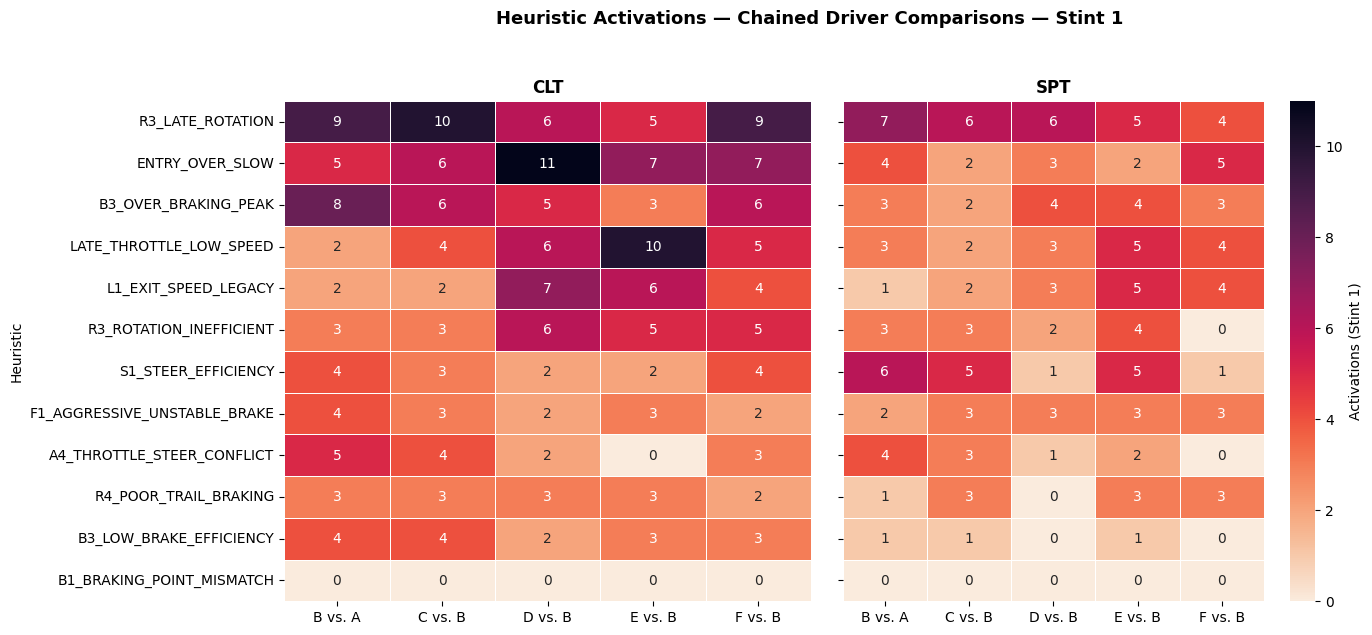

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True,
                         gridspec_kw={"wspace": 0.06,
                                      "width_ratios": [snap["CLT"].shape[1] if "CLT" in snap else 1,
                                                       snap["SPT"].shape[1] if "SPT" in snap else 1]})
vmax = snap.values.max()

for ax, track in zip(axes, ["CLT", "SPT"]):
    sub = snap[track]
    sns.heatmap(sub, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax,
                cbar=(track == "SPT"), ax=ax, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Activations (Stint 1)"})
    ax.set_title(f"{track}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Heuristic" if track == "CLT" else "")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Heuristic Activations — Chained Driver Comparisons — Stint 1",
             fontsize=13, fontweight="bold", y=1.02)
plt.savefig(SAVE_DIR / "fig_heuristics_stint1_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. Longitudinal analysis — activations along stints
Same chained comparisons (B vs. A; C/D/E/F vs. B), tracked across `stint_1 … stint_5`.

**Panel A (macro):** total activations per stint — one line per comparison, one facet per track.

**Panel B (micro):** per-comparison heatmap `heuristic × stint` — shows *which* failure modes persist vs. resolve.

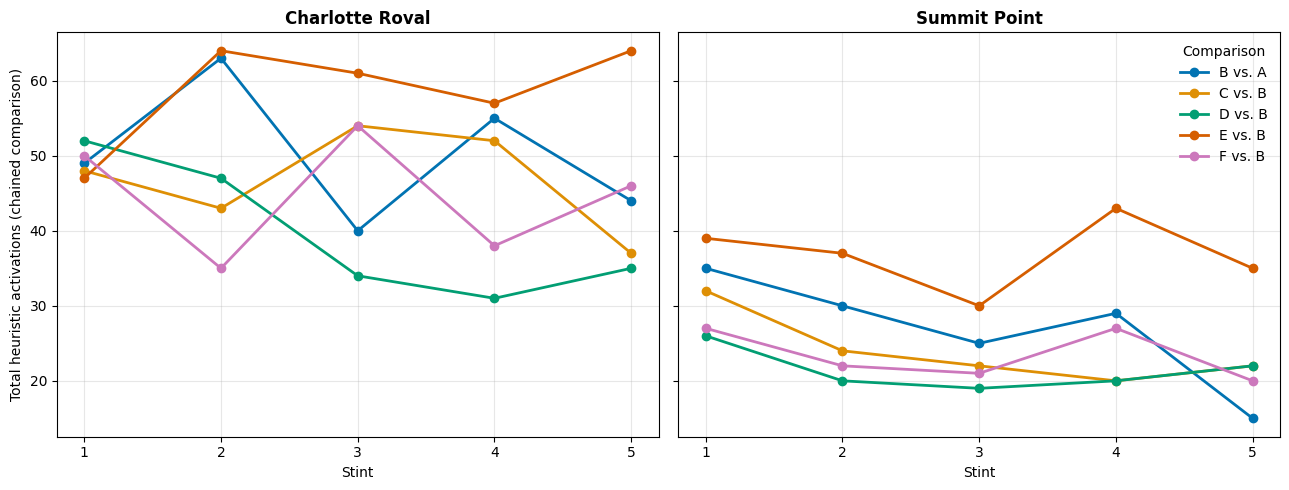

StintN               1     2     3     4     5
Track Comparison                              
CLT   B vs. A     49.0  63.0  40.0  55.0  44.0
      C vs. B     48.0  43.0  54.0  52.0  37.0
      D vs. B     52.0  47.0  34.0  31.0  35.0
      E vs. B     47.0  64.0  61.0  57.0  64.0
      F vs. B     50.0  35.0  54.0  38.0  46.0
SPT   B vs. A     35.0  30.0  25.0  29.0  15.0
      C vs. B     32.0  24.0  22.0  20.0  22.0
      D vs. B     26.0  20.0  19.0  20.0  22.0
      E vs. B     39.0  37.0  30.0  43.0  35.0
      F vs. B     27.0  22.0  21.0  27.0  20.0

In [ ]:
# --- Panel A: total activations per stint -----------------------------
tot = (df_long.groupby(["Track", "Comparison", "Stint"], as_index=False)["Fired"].sum())
tot["StintN"] = tot["Stint"].str.extract(r"(\d+)").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
palette = dict(zip(comp_order, sns.color_palette("colorblind", len(comp_order))))

for ax, track in zip(axes, ["CLT", "SPT"]):
    sub = tot[tot["Track"] == track]
    for comp, g in sub.groupby("Comparison"):
        g = g.sort_values("StintN")
        ax.plot(g["StintN"], g["Fired"], marker="o", linewidth=2,
                color=palette[comp], label=comp)
    ax.set_title({"CLT": "Charlotte Roval", "SPT": "Summit Point"}[track],
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Stint")
    ax.set_xticks(sorted(sub["StintN"].unique()))
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Total heuristic activations (chained comparison)")
axes[1].legend(title="Comparison", frameon=False, loc="upper right")
#fig.suptitle("Heuristic Activation Trajectories Across Stints",             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig_activations_per_stint_lines.pdf", dpi=300, bbox_inches="tight")
plt.show()

tot.pivot_table(index=["Track", "Comparison"], columns="StintN", values="Fired")

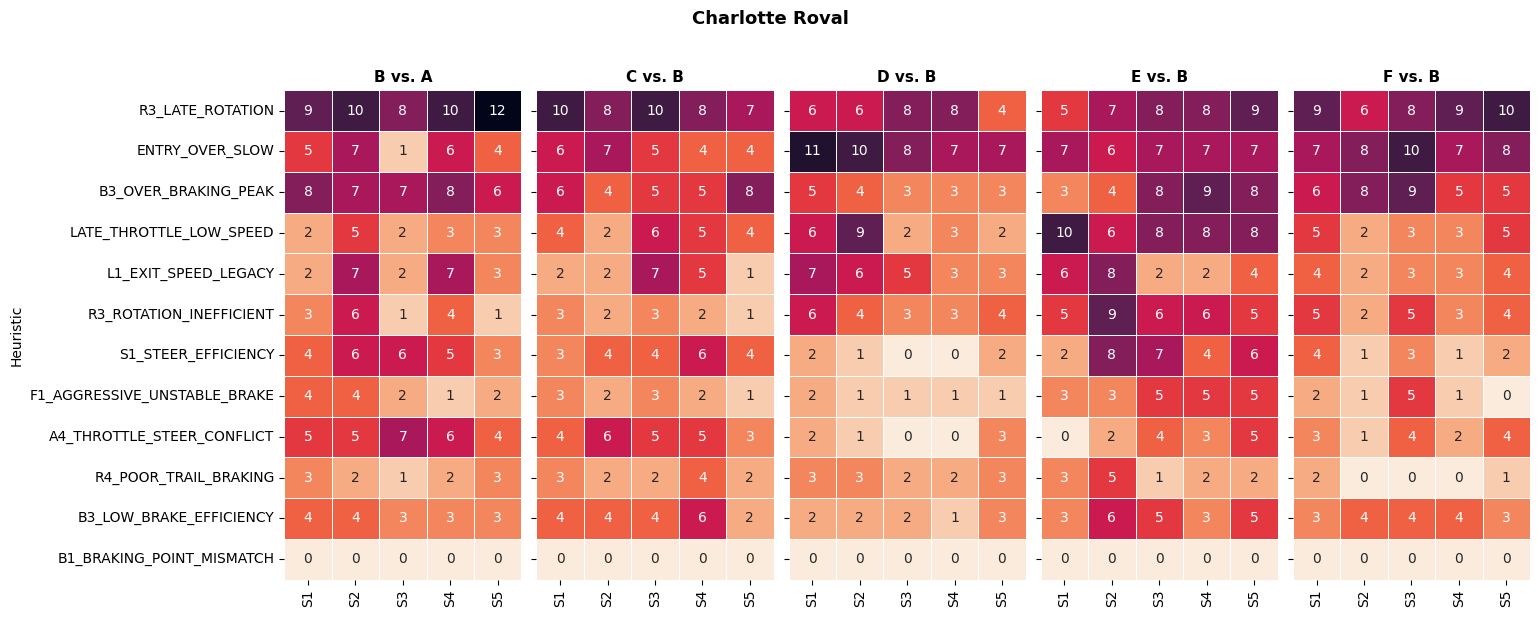

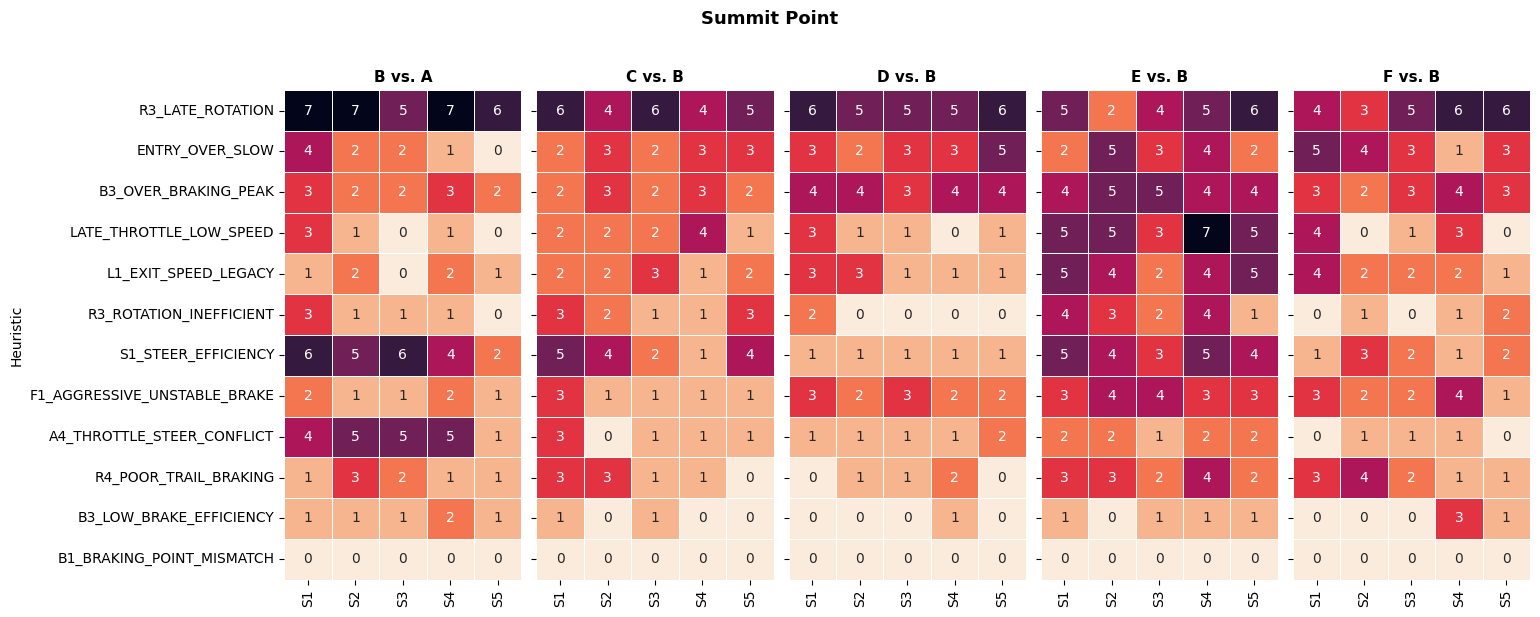

In [ ]:
# --- Panel B: per-comparison heuristic × stint heatmaps ---------------
for track in ["CLT", "SPT"]:
    sub = df_long[df_long["Track"] == track]
    comps = [c for c in comp_order if c in sub["Comparison"].unique()]
    fig, axes = plt.subplots(1, len(comps), figsize=(3.1 * len(comps), 6),
                             sharey=True)
    if len(comps) == 1:
        axes = [axes]
    vmax = sub["Fired"].max()
    for ax, comp in zip(axes, comps):
        piv = (sub[sub["Comparison"] == comp]
               .pivot_table(index="Rule_ID", columns="Stint",
                            values="Fired", fill_value=0)
               .reindex(snap.index))          # same row order as the snapshot table
        sns.heatmap(piv, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=vmax,
                    cbar=False, ax=ax, linewidths=0.5, linecolor="white")
        ax.set_title(comp, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Heuristic" if ax is axes[0] else "")
        ax.set_xticklabels([c.get_text().replace("stint_", "S") for c in ax.get_xticklabels()])
    fig.suptitle(f"{'Charlotte Roval' if track == 'CLT' else 'Summit Point'}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"fig_heuristics_stints_{track.lower()}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

## 7. Manuscript exports — summary
Generated in `Iracing/img/batch_heuristics_v4/`:

| Artifact | Use in v4 |
|---|---|
| `table7_stint1.tex` | Direct replacement for Table 7 (chained comparisons, 6 drivers) |
| `fig_heuristics_stint1_heatmap.png` | Alternative Figure for Section 6.3 (Gestalt) |
| `fig_activations_per_stint_lines.png` | New longitudinal subsection (macro trend) |
| `fig_heuristics_stints_clt.png` / `_spt.png` | Supplementary: per-driver persistence |
| `heuristic_activations_long.csv` | Reproducibility artifact (tidy data) |
| `best_laps_per_stint.csv` | Appendix: lap selection audit trail |

**Banana Rule:** heuristic identifiers are emitted verbatim (`\texttt{R3\_LATE\_ROTATION}`)
— identical strings in table, figures, and prose.